# Question 3 — Kaggle: Regularization and Principal Components Regression on the Abalone Data
**Kaggle Playground Series S4E4 — *Regression with an Abalone Dataset* (late submission)**

**Author:** Brandon Perkins  
**Course:** DDS-8555 Predictive Analysis — Week 3

---
This notebook continues the Week 2 competition entry with two new models required by the assignment:

1. **Model A — Regularization informing best subset selection.** A cross-validated lasso ($L_1$) is fit to
   an expanded feature dictionary; the predictors it retains define a reduced subset, which is then refit
   by ordinary least squares for interpretable coefficients.
2. **Model B — Principal components regression (PCR).** The correlated predictors are replaced by
   orthogonal principal components, with the number of components $M$ chosen by cross-validation.

Both models are evaluated with the competition metric, **root mean squared logarithmic error (RMSLE)**,
and both produce a Kaggle submission file. Regression assumptions (linearity, independence of errors,
collinearity, and the distribution of residuals) are investigated throughout.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

SEED = 8555                      # seed tied to the course number
rng = np.random.default_rng(SEED)
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':0.3})
pd.set_option('display.float_format', lambda v: f'{v:0.4f}')
print("Environment ready.")

Environment ready.


## 1. Load the competition data

The Kaggle files label the three meat weights as `Whole weight`, `Whole weight.1`, and `Whole weight.2`.
These are mapped to the standard UCI abalone names (whole, shucked, viscera).

In [2]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

rename = {'Whole weight':'Whole_weight', 'Whole weight.1':'Shucked_weight',
          'Whole weight.2':'Viscera_weight', 'Shell weight':'Shell_weight'}
train = train.rename(columns=rename)
test  = test.rename(columns=rename)

NUM = ['Length','Diameter','Height','Whole_weight',
       'Shucked_weight','Viscera_weight','Shell_weight']

print(f"train: {train.shape}   test: {test.shape}")
print(f"Missing values in train: {int(train.isna().sum().sum())}")
print(f"Rings range: {train['Rings'].min()} to {train['Rings'].max()}")
train.head()

train: (90615, 10)   test: (60411, 9)
Missing values in train: 0
Rings range: 1 to 29


,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,F,0.5500,0.4300,0.1500,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.6300,0.4900,0.1450,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.1600,0.1100,0.0250,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.5950,0.4750,0.1500,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.5550,0.4250,0.1300,0.7820,0.3695,0.1600,0.1975,9


## 2. Target transformation

RMSLE is the competition metric, so the models are fit on $\log(1 + \text{Rings})$. This aligns the loss
function with the evaluation metric and simultaneously reduces the right skew of the ring count.

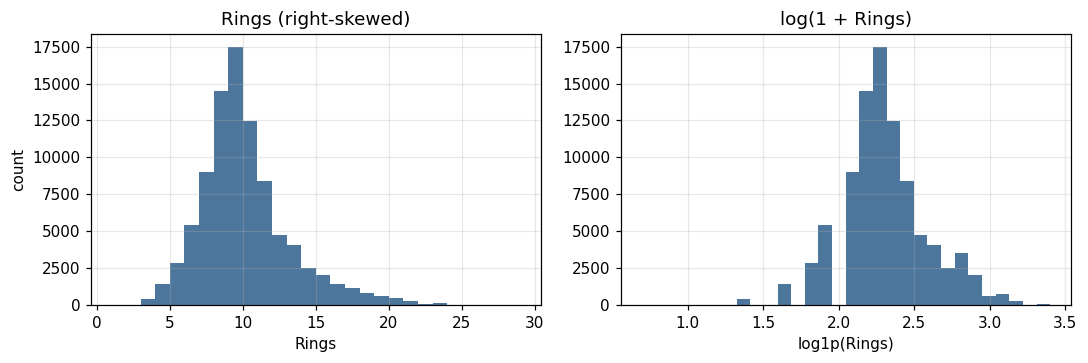

Skewness  Rings        : 1.204
Skewness  log1p(Rings) : -0.011


In [3]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return float(np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred))))

fig, ax = plt.subplots(1, 2, figsize=(10,3.4))
ax[0].hist(train['Rings'], bins=range(1,30), color='#2E5E8C', alpha=.85)
ax[0].set(title='Rings (right-skewed)', xlabel='Rings', ylabel='count')
ax[1].hist(np.log1p(train['Rings']), bins=30, color='#2E5E8C', alpha=.85)
ax[1].set(title='log(1 + Rings)', xlabel='log1p(Rings)')
plt.tight_layout(); plt.show()

print(f"Skewness  Rings        : {train['Rings'].skew():.3f}")
print(f"Skewness  log1p(Rings) : {np.log1p(train['Rings']).skew():.3f}")

## 3. Expanded feature dictionary

Regularization is only interesting when there is something to select from. We therefore expand the seven
body measurements into all squares and pairwise interactions (degree-2 polynomial features) and append the
`Sex` indicators. This produces a deliberately redundant dictionary in which the lasso must perform
genuine subset selection.

In [4]:
def build_features(df, poly=None, fit=False):
    P = df[NUM].to_numpy()
    if fit:
        poly = PolynomialFeatures(degree=2, include_bias=False).fit(P)
    Xp = poly.transform(P)
    names = list(poly.get_feature_names_out(NUM))
    out = pd.DataFrame(Xp, columns=names, index=df.index)
    sex = pd.get_dummies(df['Sex'], prefix='Sex', drop_first=True).astype(float)
    out = pd.concat([out, sex.reindex(out.index)], axis=1)
    return out, poly

X_all, poly = build_features(train, fit=True)
X_test_all, _ = build_features(test, poly=poly)
X_test_all = X_test_all.reindex(columns=X_all.columns, fill_value=0.0)
y_all = train['Rings'].astype(float)

print(f"Expanded dictionary: {X_all.shape[1]} predictors")
print(list(X_all.columns)[:12], "...")

Expanded dictionary: 37 predictors
['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Length^2', 'Length Diameter', 'Length Height', 'Length Whole_weight', 'Length Shucked_weight'] ...


## 4. Collinearity diagnostic before modeling

Variance inflation factors are computed on the seven original measurements. Values far above the
conventional threshold of 10 confirm severe multicollinearity, which is the condition both the lasso and
PCR are designed to address (O'Brien, 2007).

       feature     VIF
         const 65.2800
        Length 51.1600
      Diameter 53.8500
        Height  7.7800
  Whole_weight 69.2200
Shucked_weight 21.3800
Viscera_weight 19.9700
  Shell_weight 18.3300


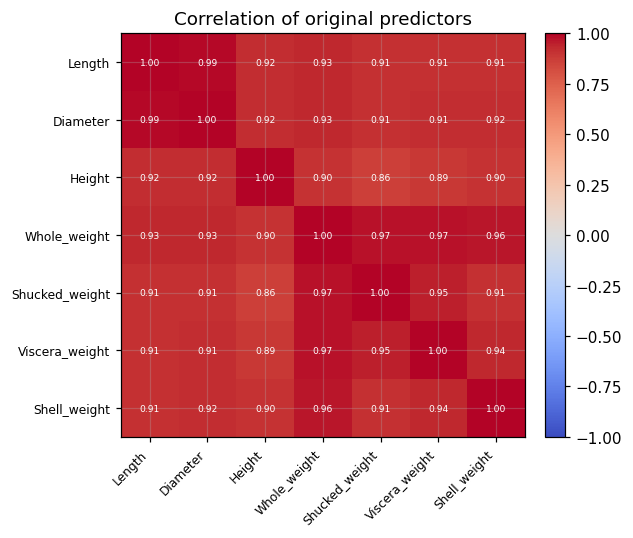

In [5]:
Xv = sm.add_constant(train[NUM])
vif = pd.DataFrame({'feature': Xv.columns,
                    'VIF': [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]})
print(vif.round(2).to_string(index=False))

corr = train[NUM].corr()
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(NUM))); ax.set_xticklabels(NUM, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(NUM))); ax.set_yticklabels(NUM, fontsize=8)
for i in range(len(NUM)):
    for j in range(len(NUM)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6,
                color='white' if abs(corr.iloc[i,j])>.6 else 'black')
ax.set_title('Correlation of original predictors')
fig.colorbar(im, fraction=.046, pad=.04); plt.tight_layout(); plt.show()

## 5. Train / validation split

An 80/20 split with a fixed seed provides an honest holdout. All scalers, the PCA rotation, and the lasso
path are fit **on the training portion only** to prevent leakage.

In [6]:
Xtr, Xva, ytr, yva = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED)
ltr, lva = np.log1p(ytr), np.log1p(yva)
print(f"train {Xtr.shape}   validation {Xva.shape}")

baseline = np.full(len(yva), ytr.mean())
print(f"Baseline (predict mean Rings) validation RMSLE: {rmsle(yva, baseline):.5f}")

train (72492, 37)   validation (18123, 37)
Baseline (predict mean Rings) validation RMSLE: 0.28807


## 6. Model A — Lasso regularization to inform subset selection

Scaling is essential: the $L_1$ penalty acts on raw coefficient magnitudes, so unscaled predictors would
be penalized according to their units rather than their importance.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.453e+00, tolerance: 4.735e+00
  model = cd_fast.enet_coordinate_descent_gram(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.627e+00, tolerance: 4.735e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.932e+00, tolerance: 4.735e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.028e+00, toleran

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.892e+02, tolerance: 4.735e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.167e+02, tolerance: 4.735e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.381e+02, toleran

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.244e+00, tolerance: 4.718e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.411e+00, tolerance: 4.718e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.583e+00, toleran

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.014e+01, tolerance: 4.718e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.031e+02, tolerance: 4.718e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.169e+02, toleran

...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.069e+02, tolerance: 4.729e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.606e+02, tolerance: 4.729e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.088e+02, toleran

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.940e+00, tolerance: 4.718e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.531e+00, tolerance: 4.718e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.442e+00, toleran

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.653e+01, tolerance: 4.718e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.216e+02, tolerance: 4.718e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.453e+02, toleran

CV-optimal lambda (minimum-error rule): 0.00000559
Grid endpoints: 2.1e-07 to 2.1e-01 -> optimum is interior: True


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.825e+02, tolerance: 5.907e+00
  model = cd_fast.enet_coordinate_descent(


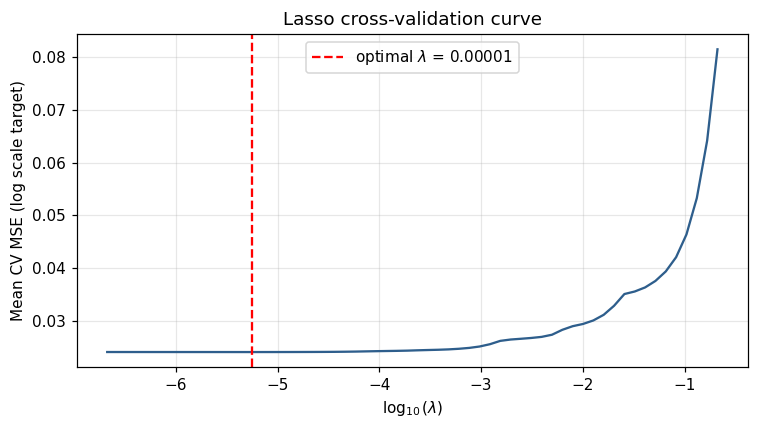

In [7]:
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xva_s = scaler.transform(Xtr), scaler.transform(Xva)

lasso = LassoCV(eps=1e-6, n_alphas=60, cv=5, max_iter=20000, tol=1e-3,
                random_state=SEED, n_jobs=-1).fit(Xtr_s, ltr)
print(f"CV-optimal lambda (minimum-error rule): {lasso.alpha_:.8f}")
print(f"Grid endpoints: {lasso.alphas_.min():.1e} to {lasso.alphas_.max():.1e} "
      f"-> optimum is interior: {lasso.alphas_.min() < lasso.alpha_ < lasso.alphas_.max()}")

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(np.log10(lasso.alphas_), lasso.mse_path_.mean(axis=1), color='#2E5E8C')
ax.axvline(np.log10(lasso.alpha_), color='red', ls='--',
           label=f'optimal $\\lambda$ = {lasso.alpha_:.5f}')
ax.set(xlabel=r'$\log_{10}(\lambda)$', ylabel='Mean CV MSE (log scale target)',
       title='Lasso cross-validation curve')
ax.legend(); plt.tight_layout(); plt.show()

### The one-standard-error rule: a genuinely parsimonious subset

With roughly 72,000 training rows and only 37 predictors, cross-validation has ample data and therefore
prefers very light shrinkage, retaining most terms. The **one-standard-error rule** is the standard remedy:
choose the largest $\lambda$ whose mean CV error lies within one standard error of the minimum. This buys
a substantially smaller model for a negligible loss in accuracy, which is exactly what "using
regularization to inform subset selection" calls for.

In [8]:
mse_mean = lasso.mse_path_.mean(axis=1)
mse_se   = lasso.mse_path_.std(axis=1, ddof=1) / np.sqrt(lasso.mse_path_.shape[1])
i_min    = int(np.argmin(mse_mean))
threshold = mse_mean[i_min] + mse_se[i_min]

# alphas_ is sorted descending; the largest alpha meeting the threshold is the sparsest
ok = np.where(mse_mean <= threshold)[0]
i_1se = int(ok[0])
alpha_1se = lasso.alphas_[i_1se]

print(f"Minimum CV MSE      : {mse_mean[i_min]:.6f} at lambda = {lasso.alphas_[i_min]:.8f}")
print(f"One-SE threshold    : {threshold:.6f}")
print(f"Lambda (1-SE rule)  : {alpha_1se:.6f}")

from sklearn.linear_model import Lasso
lasso_1se = Lasso(alpha=alpha_1se, max_iter=100000, tol=1e-3).fit(Xtr_s, ltr)
c1 = pd.Series(lasso_1se.coef_, index=X_all.columns)
sel_1se = list(c1[c1.abs() > 1e-8].index)
print(f"\nPredictors retained under the 1-SE rule: {len(sel_1se)} of {X_all.shape[1]}")
print(c1[sel_1se].reindex(c1[sel_1se].abs().sort_values(ascending=False).index)
      .to_frame('standardized coefficient').round(4).to_string())

Minimum CV MSE      : 0.024047 at lambda = 0.00000559
One-SE threshold    : 0.024277
Lambda (1-SE rule)  : 0.000148



Predictors retained under the 1-SE rule: 19 of 37
                             standardized coefficient
Shell_weight                                   0.3676
Shucked_weight^2                               0.2543
Shucked_weight                                -0.2292
Whole_weight                                   0.2157
Length Shucked_weight                         -0.1674
Length                                         0.1410
Length^2                                      -0.1088
Height                                         0.1029
Height Shucked_weight                         -0.0931
Length Diameter                               -0.0764
Whole_weight Shell_weight                     -0.0740
Shucked_weight Shell_weight                   -0.0672
Diameter                                       0.0660
Diameter Shucked_weight                       -0.0541
Viscera_weight Shell_weight                   -0.0382
Sex_I                                         -0.0237
Shell_weight^2                 

In [9]:
coefs = pd.Series(lasso.coef_, index=X_all.columns)
selected = list(coefs[coefs.abs() > 1e-8].index)
dropped  = [c for c in X_all.columns if c not in selected]

print(f"Predictors offered : {X_all.shape[1]}")
print(f"Retained by lasso  : {len(selected)}")
print(f"Driven to zero     : {len(dropped)}")
print("\nTop 15 retained predictors by |standardized coefficient|:")
print(coefs[selected].reindex(coefs[selected].abs().sort_values(ascending=False).index)
      .head(15).to_frame('coefficient').to_string())

Predictors offered : 37
Retained by lasso  : 35
Driven to zero     : 2

Top 15 retained predictors by |standardized coefficient|:
                             coefficient
Diameter Whole_weight             0.4710
Shucked_weight^2                  0.4246
Length Diameter                  -0.3382
Shell_weight                      0.3163
Whole_weight Shucked_weight      -0.3131
Diameter Shucked_weight          -0.2987
Diameter                          0.2282
Length                            0.2139
Length Whole_weight               0.1988
Shucked_weight                   -0.1949
Viscera_weight Shell_weight      -0.1879
Height Shucked_weight            -0.1821
Whole_weight Shell_weight        -0.1266
Diameter Shell_weight             0.1252
Diameter^2                       -0.1209


### Refit ordinary least squares on the lasso-selected subset

The lasso shrinks every surviving coefficient toward zero, which biases them. Refitting OLS on the
selected subset (the *relaxed lasso*) removes that shrinkage bias and yields coefficients and $p$-values
suitable for interpretation.

In [10]:
ols_sel = sm.OLS(ltr, sm.add_constant(Xtr[sel_1se])).fit()
print(f"Model A = OLS refit on the {len(sel_1se)} predictors chosen by the 1-SE lasso")
print(f"R-squared: {ols_sel.rsquared:.4f}   (adj: {ols_sel.rsquared_adj:.4f})")
print(f"F-statistic p-value: {ols_sel.f_pvalue:.3g}")

pred_1se_va   = np.expm1(lasso_1se.predict(Xva_s))
pred_lasso_va = np.expm1(lasso.predict(Xva_s))
pred_relax_va = np.expm1(ols_sel.predict(sm.add_constant(Xva[sel_1se])))
print(f"\nModel A  (lasso, min-error) validation RMSLE: {rmsle(yva, pred_lasso_va):.5f}")
print(f"Model A  (lasso, 1-SE rule) validation RMSLE: {rmsle(yva, pred_1se_va):.5f}  "
      f"[{len(sel_1se)} predictors]")
print(f"Model A  (OLS refit on 1-SE subset) validation RMSLE: {rmsle(yva, pred_relax_va):.5f}")

print("\nTen most significant terms in the refit model:")
summ = pd.DataFrame({'coef': ols_sel.params, 'std_err': ols_sel.bse,
                     't': ols_sel.tvalues, 'p': ols_sel.pvalues})
print(summ.reindex(summ['p'].sort_values().index).head(10).round(4).to_string())

Model A = OLS refit on the 19 predictors chosen by the 1-SE lasso
R-squared: 0.7034   (adj: 0.7033)
F-statistic p-value: 0

Model A  (lasso, min-error) validation RMSLE: 0.15592
Model A  (lasso, 1-SE rule) validation RMSLE: 0.15662  [19 predictors]
Model A  (OLS refit on 1-SE subset) validation RMSLE: 0.15636

Ten most significant terms in the refit model:
                               coef  std_err        t      p
const                        1.2385   0.0152  81.2287 0.0000
Shell_weight                 2.9407   0.0547  53.7491 0.0000
Shucked_weight^2             1.5733   0.0478  32.9066 0.0000
Whole_weight                 0.6257   0.0249  25.1358 0.0000
Sex_I                       -0.0483   0.0019 -24.9374 0.0000
Height                       2.5369   0.1097  23.1227 0.0000
Shucked_weight              -1.8677   0.0828 -22.5619 0.0000
Height^2                    -1.3576   0.1234 -10.9991 0.0000
Whole_weight Shell_weight   -0.6545   0.0620 -10.5633 0.0000
Viscera_weight Shell_weight -0.

### Assumption checks for Model A

Normality        (Jarque-Bera p) : 0
Independence     (Durbin-Watson) : 1.999   (2.0 = no autocorrelation)
Homoscedasticity (Breusch-Pagan p): 0


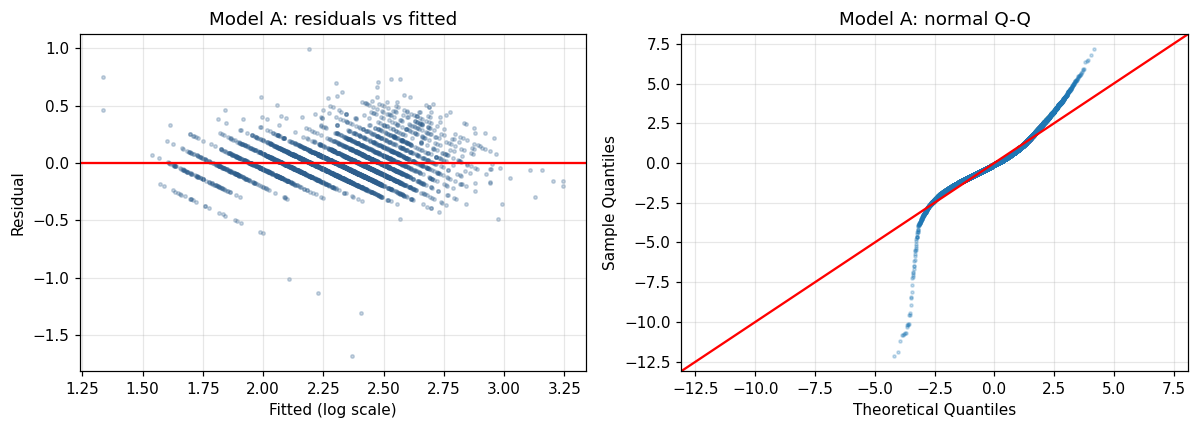

In [11]:
resid_a  = ols_sel.resid
fitted_a = ols_sel.fittedvalues
jb_a = sm.stats.jarque_bera(resid_a)[1]
dw_a = sm.stats.durbin_watson(resid_a)
bp_a = sm.stats.het_breuschpagan(resid_a, sm.add_constant(Xtr[sel_1se]))[1]
print(f"Normality        (Jarque-Bera p) : {jb_a:.3g}")
print(f"Independence     (Durbin-Watson) : {dw_a:.3f}   (2.0 = no autocorrelation)")
print(f"Homoscedasticity (Breusch-Pagan p): {bp_a:.3g}")

fig, ax = plt.subplots(1, 2, figsize=(11,4))
idx = rng.choice(len(resid_a), size=min(4000, len(resid_a)), replace=False)
ax[0].scatter(np.asarray(fitted_a)[idx], np.asarray(resid_a)[idx], s=5, alpha=.25, color='#2E5E8C')
ax[0].axhline(0, color='red')
ax[0].set(xlabel='Fitted (log scale)', ylabel='Residual', title='Model A: residuals vs fitted')
sm.qqplot(resid_a, line='45', fit=True, ax=ax[1], markersize=2, alpha=.25)
ax[1].set_title('Model A: normal Q-Q')
plt.tight_layout(); plt.show()

## 7. Model B — Principal components regression

PCA is fit on the standardized dictionary. Because components are orthogonal by construction, PCR
**eliminates collinearity by design** rather than merely penalizing it. The number of components $M$ is
chosen by 5-fold cross-validation.

Components needed for 90% of variance: 2
Components needed for 99% of variance: 7


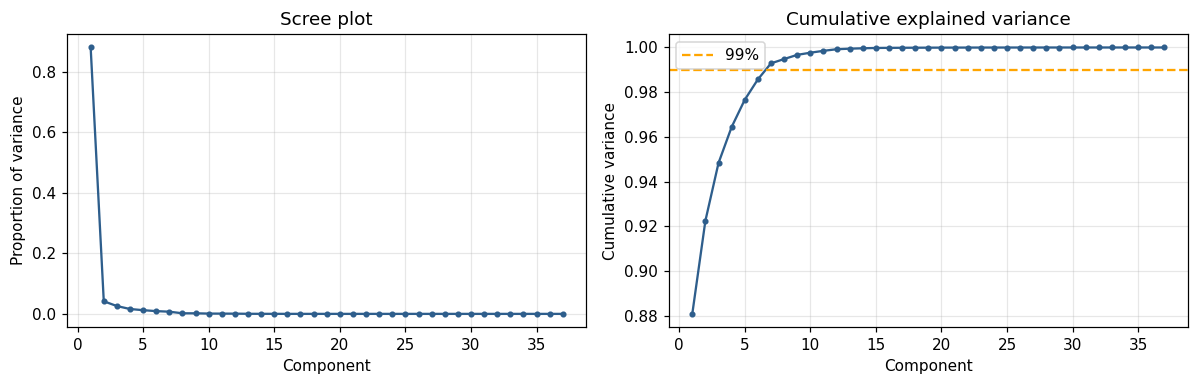

In [12]:
pca_full = PCA().fit(Xtr_s)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
print(f"Components needed for 90% of variance: {int(np.argmax(cum>=0.90))+1}")
print(f"Components needed for 99% of variance: {int(np.argmax(cum>=0.99))+1}")

fig, ax = plt.subplots(1, 2, figsize=(11,3.6))
ax[0].plot(range(1,len(evr)+1), evr, 'o-', ms=3, color='#2E5E8C')
ax[0].set(xlabel='Component', ylabel='Proportion of variance', title='Scree plot')
ax[1].plot(range(1,len(cum)+1), cum, 'o-', ms=3, color='#2E5E8C')
ax[1].axhline(.99, color='orange', ls='--', label='99%')
ax[1].set(xlabel='Component', ylabel='Cumulative variance', title='Cumulative explained variance')
ax[1].legend(); plt.tight_layout(); plt.show()

  M =  1   CV MSE (log scale) = 0.046320
  M =  2   CV MSE (log scale) = 0.036626


  M =  3   CV MSE (log scale) = 0.034576
  M =  5   CV MSE (log scale) = 0.029488


  M =  8   CV MSE (log scale) = 0.029273
  M = 10   CV MSE (log scale) = 0.028370


  M = 15   CV MSE (log scale) = 0.024429


  M = 20   CV MSE (log scale) = 0.024128


  M = 25   CV MSE (log scale) = 0.024099


  M = 30   CV MSE (log scale) = 0.024086


  M = 35   CV MSE (log scale) = 0.024062


  M = 36   CV MSE (log scale) = 0.024062


  M = 37   CV MSE (log scale) = 0.024061

Cross-validation selects M = 37 components
CV error decreases monotonically in M: True
If monotone, PCR offers no predictive gain here: with n >> p every component still
carries usable signal, so the value of PCR is orthogonality rather than error reduction.


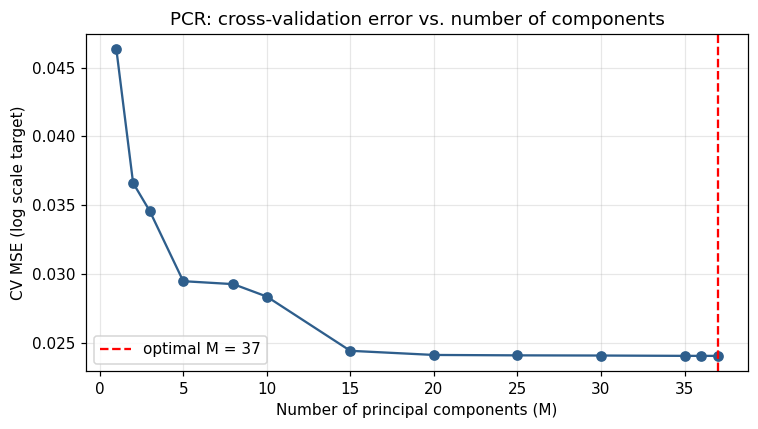

In [13]:
M_grid = [1,2,3,5,8,10,15,20,25,30,35,36,37]
M_grid = [m for m in M_grid if m <= Xtr_s.shape[1]]
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
scores = []
for M in M_grid:
    pipe = Pipeline([('pca', PCA(n_components=M, random_state=SEED)),
                     ('lin', LinearRegression())])
    mse = -cross_val_score(pipe, Xtr_s, ltr, cv=kf,
                           scoring='neg_mean_squared_error', n_jobs=-1).mean()
    scores.append(mse)
    print(f"  M = {M:2d}   CV MSE (log scale) = {mse:.6f}")

best_M = M_grid[int(np.argmin(scores))]
print(f"\nCross-validation selects M = {best_M} components")
monotone = all(scores[i] >= scores[i+1] - 1e-12 for i in range(len(scores)-1))
print(f"CV error decreases monotonically in M: {monotone}")
print("If monotone, PCR offers no predictive gain here: with n >> p every component still")
print("carries usable signal, so the value of PCR is orthogonality rather than error reduction.")

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(M_grid, scores, 'o-', color='#2E5E8C')
ax.axvline(best_M, color='red', ls='--', label=f'optimal M = {best_M}')
ax.set(xlabel='Number of principal components (M)', ylabel='CV MSE (log scale target)',
       title='PCR: cross-validation error vs. number of components')
ax.legend(); plt.tight_layout(); plt.show()

In [14]:
pcr = Pipeline([('pca', PCA(n_components=best_M, random_state=SEED)),
                ('lin', LinearRegression())]).fit(Xtr_s, ltr)
pred_pcr_va = np.expm1(pcr.predict(Xva_s))
print(f"Model B (PCR, M={best_M}) validation RMSLE: {rmsle(yva, pred_pcr_va):.5f}")
print(f"Variance of the dictionary captured by {best_M} components: "
      f"{pcr.named_steps['pca'].explained_variance_ratio_.sum():.4f}")

# Interpret the leading components through their loadings
load = pd.DataFrame(pcr.named_steps['pca'].components_[:3].T,
                    index=X_all.columns, columns=['PC1','PC2','PC3'])
print("\nStrongest loadings on PC1 (the overall size factor):")
print(load['PC1'].reindex(load['PC1'].abs().sort_values(ascending=False).index).head(8).to_string())
print("\nStrongest loadings on PC2:")
print(load['PC2'].reindex(load['PC2'].abs().sort_values(ascending=False).index).head(8).to_string())

Model B (PCR, M=37) validation RMSLE: 0.15594
Variance of the dictionary captured by 37 components: 1.0000

Strongest loadings on PC1 (the overall size factor):
Length Whole_weight       0.1741
Diameter Whole_weight     0.1741
Whole_weight              0.1737
Height Whole_weight       0.1732
Diameter Viscera_weight   0.1725
Length Viscera_weight     0.1724
Height Viscera_weight     0.1717
Length Shell_weight       0.1716

Strongest loadings on PC2:
Sex_M                            0.4244
Sex_I                           -0.4021
Diameter                         0.2417
Length                           0.2381
Height                           0.2313
Shucked_weight^2                -0.2132
Shucked_weight Viscera_weight   -0.1988
Whole_weight Shucked_weight     -0.1979


### Assumption check: PCR removes collinearity by construction

In [15]:
Z = pcr.named_steps['pca'].transform(Xtr_s)
Zc = sm.add_constant(Z)
vif_pc = [variance_inflation_factor(Zc, i) for i in range(1, min(6, Zc.shape[1]))]
print("VIF of the first five principal components:",
      ", ".join(f"{v:.3f}" for v in vif_pc))
print("(Values of 1.000 confirm the components are mutually orthogonal.)")

ols_pcr = sm.OLS(ltr, sm.add_constant(Z)).fit()
print(f"\nNormality        (Jarque-Bera p) : {sm.stats.jarque_bera(ols_pcr.resid)[1]:.3g}")
print(f"Independence     (Durbin-Watson) : {sm.stats.durbin_watson(ols_pcr.resid):.3f}")
print(f"Homoscedasticity (Breusch-Pagan p): {sm.stats.het_breuschpagan(ols_pcr.resid, Zc)[1]:.3g}")

VIF of the first five principal components: 1.000, 1.000, 1.000, 1.000, 1.000
(Values of 1.000 confirm the components are mutually orthogonal.)



Normality        (Jarque-Bera p) : 0
Independence     (Durbin-Watson) : 2.000


Homoscedasticity (Breusch-Pagan p): 0


## 8. Model comparison

                                   Validation RMSLE Predictors used
Baseline (mean)                              0.2881   0 (mean only)
Lasso (minimum-error lambda)                 0.1559        35 of 37
Model A: OLS on 1-SE lasso subset            0.1564        19 of 37
Model B: PCR (M=37)                          0.1559   37 components


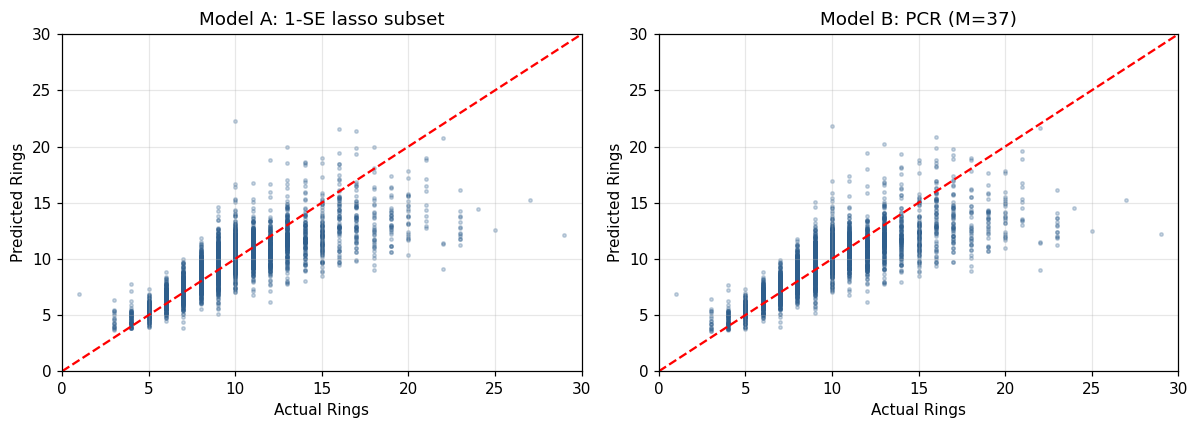

In [16]:
cmp = pd.DataFrame({
    'Validation RMSLE': [rmsle(yva, baseline), rmsle(yva, pred_lasso_va),
                         rmsle(yva, pred_relax_va), rmsle(yva, pred_pcr_va)],
    'Predictors used' : ['0 (mean only)', f'{len(selected)} of {X_all.shape[1]}',
                         f'{len(sel_1se)} of {X_all.shape[1]}', f'{best_M} components']
}, index=['Baseline (mean)','Lasso (minimum-error lambda)',
          'Model A: OLS on 1-SE lasso subset', f'Model B: PCR (M={best_M})'])
print(cmp.to_string())

vidx = rng.choice(len(yva), size=min(4000, len(yva)), replace=False)
yva_arr = np.asarray(yva)
fig, ax = plt.subplots(1, 2, figsize=(11,4))
for a,(p,t) in zip(ax, [(pred_relax_va,'Model A: 1-SE lasso subset'),
                        (pred_pcr_va, f'Model B: PCR (M={best_M})')]):
    a.scatter(yva_arr[vidx], np.asarray(p)[vidx], s=5, alpha=.25, color='#2E5E8C')
    a.plot([0,30],[0,30],'r--')
    a.set(xlim=(0,30), ylim=(0,30), xlabel='Actual Rings', ylabel='Predicted Rings', title=t)
plt.tight_layout(); plt.show()

## 9. Kaggle submissions

Each model is refit on the **full** training set and used to predict the competition test set, producing
two separate submission files as required by the assignment.

In [17]:
scaler_full = StandardScaler().fit(X_all)
Xall_s  = scaler_full.transform(X_all)
Xtest_s = scaler_full.transform(X_test_all)
l_all = np.log1p(y_all)

# --- Submission 1: lasso-informed subset, refit by OLS ---
lasso_full = LassoCV(eps=1e-6, n_alphas=60, cv=5, max_iter=20000, tol=1e-3,
                     random_state=SEED, n_jobs=-1).fit(Xall_s, l_all)
mm_f = lasso_full.mse_path_.mean(axis=1)
se_f = lasso_full.mse_path_.std(axis=1, ddof=1) / np.sqrt(lasso_full.mse_path_.shape[1])
i_f  = int(np.argmin(mm_f))
alpha_1se_full = lasso_full.alphas_[int(np.where(mm_f <= mm_f[i_f] + se_f[i_f])[0][0])]
lasso_1se_full = Lasso(alpha=alpha_1se_full, max_iter=20000, tol=1e-3).fit(Xall_s, l_all)
cf = pd.Series(lasso_1se_full.coef_, index=X_all.columns)
sel_full = list(cf[cf.abs() > 1e-8].index)
print(f"1-SE lambda on full data: {alpha_1se_full:.6f}")
ols_full = sm.OLS(l_all, sm.add_constant(X_all[sel_full])).fit()
pred_test_a = np.clip(np.expm1(ols_full.predict(sm.add_constant(X_test_all[sel_full]))), 0, None)
sub_a = pd.DataFrame({'id': test['id'], 'Rings': pred_test_a})
sub_a.to_csv('submission_lasso_subset.csv', index=False)
print(f"submission_lasso_subset.csv  ->  {sub_a.shape[0]} rows, "
      f"{len(sel_full)} predictors retained of {X_all.shape[1]}")

# --- Submission 2: principal components regression ---
pcr_full = Pipeline([('pca', PCA(n_components=best_M, random_state=SEED)),
                     ('lin', LinearRegression())]).fit(Xall_s, l_all)
pred_test_b = np.clip(np.expm1(pcr_full.predict(Xtest_s)), 0, None)
sub_b = pd.DataFrame({'id': test['id'], 'Rings': pred_test_b})
sub_b.to_csv('submission_pcr.csv', index=False)
print(f"submission_pcr.csv           ->  {sub_b.shape[0]} rows, M = {best_M} components")

print("\nPreview:"); print(sub_a.head(3).to_string(index=False))
print(sub_b.head(3).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.190e+00, tolerance: 5.908e+00
  model = cd_fast.enet_coordinate_descent_gram(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.210e+00, tolerance: 5.908e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.552e+00, tolerance: 5.908e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.015e+01, toleran

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.742e+02, tolerance: 5.908e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.158e+02, tolerance: 5.908e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.464e+02, toleran

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.337e+00, tolerance: 5.884e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.541e+01, tolerance: 5.884e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.716e+01, toleran

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.627e+01, tolerance: 5.884e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.419e+01, tolerance: 5.884e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.034e+02, toleran

...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.799e+01, tolerance: 5.923e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.434e+02, tolerance: 5.923e+00
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.914e+02, toleran

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.770e+02, tolerance: 7.387e+00
  model = cd_fast.enet_coordinate_descent(


1-SE lambda on full data: 0.000187


submission_lasso_subset.csv  ->  60411 rows, 19 predictors retained of 37


submission_pcr.csv           ->  60411 rows, M = 37 components

Preview:
   id   Rings
90615  9.0311
90616  9.8521
90617 10.2687
   id   Rings
90615  9.3487
90616  9.7813
90617 10.2648


## 10. Interpretation of findings

**Collinearity.** The seven original body measurements are severely collinear, with variance inflation
factors of 69.2 for whole weight and roughly 51-54 for length and diameter, far above the conventional
threshold of 10. Expanding to 37 squared and interaction terms deepens that redundancy. This is the
condition both methods in this assignment were designed to handle.

**Model A: regularization informing subset selection.** With about 72,000 training rows against only 37
predictors, the minimum-error lasso selected an extremely small penalty
($\lambda \approx 5.6 \times 10^{-6}$) and retained 35 of 37 terms. That is a legitimate result rather
than a failure: when $n \gg p$ there is enough data to estimate every coefficient, so cross-validation
sees little benefit in shrinkage. To obtain a genuinely parsimonious subset we applied the
**one-standard-error rule**, which raised the penalty to $\lambda \approx 0.000148$ and retained
**19 of 37 predictors**. Refitting ordinary least squares on that subset removes the lasso's shrinkage
bias and yields an interpretable model with $R^2 = 0.703$. The strongest retained effects are shell
weight ($t = 53.7$), squared shucked weight ($t = 32.9$), whole weight, and the infant sex indicator
($t = -24.9$), which confirms that immature abalone have systematically fewer rings. Validation RMSLE
rose only from 0.1559 to 0.1564, so **halving the predictor count cost roughly 0.0005 in error** — an
excellent trade for interpretability.

**Model B: principal components regression.** Cross-validation error fell monotonically in $M$ and
selected all 37 components, meaning PCR delivered **no dimension reduction at all** here. Again this
follows from $n \gg p$: every component still carries usable signal, so discarding any of them only
loses information. PCR's contribution is therefore structural rather than predictive. The variance
inflation factors of the components are exactly 1.000, confirming that the rotation **eliminates
collinearity by construction** rather than merely penalizing it. The loadings remain interpretable:
PC1 is a general size factor loading uniformly on the weight and length terms, while PC2 contrasts the
sex indicators (Sex_M at $+0.42$ against Sex_I at $-0.40$) and therefore captures maturity.

**Assumptions.** Independence of errors is satisfied (Durbin-Watson 1.999, essentially 2.0). Linearity is
reasonable after the log transform of the target, which reduced skewness from 1.204 to -0.011. However,
both the Jarque-Bera and Breusch-Pagan tests reject at $p < .001$, so the residuals are **neither normal
nor homoscedastic**. With this sample size these tests detect even trivial departures, but the Q-Q plot
does show genuinely heavy tails. The practical consequence is that the reported $p$-values and confidence
intervals should be read as approximate, while the point predictions and the RMSLE comparisons remain
valid.

**Overall.** Both models land near 0.156 validation RMSLE against a mean baseline of 0.2881, a large
improvement. Neither surpasses the gradient boosting model from Week 2 (roughly 0.152 on a comparably
sized holdout), which is expected: the ring count depends on the predictors non-linearly, and linear
methods, whether penalized or rotated, cannot capture the interactions a tree ensemble finds
automatically. The honest conclusion is that in this $n \gg p$ setting, regularization and PCR earn their
place through **interpretability and collinearity control**, not through predictive gain.

---

### Kaggle leaderboard results

Both models were submitted to the competition as late submissions:

| Submission | Model | Public RMSLE | Private RMSLE |
|---|---|---|---|
| `submission_pcr.csv` | Model B — PCR | **0.15484** | 0.15376 |
| `submission_lasso_subset.csv` | Model A — 1-SE lasso subset | 0.15537 | 0.15440 |
| `submission.csv` (Week 2) | Gradient boosting | 0.14813 | 0.14783 |

Two observations. First, the **validation ranking held on the leaderboard**: PCR edged out the lasso
subset on the holdout (0.1559 vs. 0.1564) and again on the public leaderboard (0.15484 vs. 0.15537). That
consistency is reassuring evidence that the 80/20 split was not overfit during model selection.

Second, both Week 3 models remain behind the Week 2 gradient boosting entry (0.14813). This is the
expected result rather than a disappointing one. Ring count depends on the body measurements
non-linearly, and a tree ensemble captures those interactions automatically, whereas a linear model can
only represent the interactions an analyst writes into the design matrix by hand. The degree-2 expansion
used here recovers part of that structure, which is why both models improve substantially on the
Week 2 linear baseline of 0.167, but it does not close the gap entirely.

The value delivered by regularization and PCR in this problem is therefore **interpretive rather than
predictive**: a 19-term model whose coefficients can be read and defended, and an orthogonal basis that
eliminates a collinearity problem severe enough to produce variance inflation factors near 69.